# Fitting and selecting a predictive distribution for one asset

We want a probabilistic forecast $F$ for a single asset's risk-adjusted return,

$$m_t = \frac{r^{\text{Mkt}}_t - r^f_t}{1 + r^f_t},$$

using monthly Fama–French factor data. The workflow has three steps:

1. **Fit** three candidate parametric families (Normal, Student-$t$, Johnson SU) on **fold 1** by maximum likelihood.
2. **Select** the best of the three on **fold 2** using the continuous ranked probability score (CRPS) — closed-form for the Normal, quadrature for the others.
3. **Diagnose** the winner on fold 2 via the PIT $p_t = F(m_t)$, which should be uniform if $F$ is well calibrated.

Folds 3 and 4 are reserved for a later lecture.

In [1]:
import numpy as np
import pandas as pd
import requests
from io import BytesIO
from zipfile import ZipFile
from scipy.stats import norm, t, johnsonsu
import properscoring as ps
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
rng = np.random.default_rng(544)

## Data: Fama–French monthly factors

Download from Ken French's website, keep monthly rows, build $m_t$, and split into folds (no overlap).

In [2]:
url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"
response = requests.get(url)

with ZipFile(BytesIO(response.content)) as zfile:
    csv_name = next(n for n in zfile.namelist() if n.lower().endswith(".csv"))
    with zfile.open(csv_name) as file:
        ff = pd.read_csv(file, skiprows=3, index_col=0)

ff = ff.apply(pd.to_numeric, errors="coerce").dropna()
ff = ff[ff.index.map(lambda s: s.isdigit() and len(s) == 6)]
ff["m"] = (ff["Mkt-RF"] / 100) / (1 + ff["RF"] / 100)

ff.head()

,Mkt-RF,SMB,HML,RF,m
192607,2.89,-2.55,-2.39,0.22,0.028837
192608,2.64,-1.14,3.81,0.25,0.026334
192609,0.38,-1.36,0.05,0.23,0.003791
192610,-3.27,-0.14,0.82,0.32,-0.032596
192611,2.54,-0.11,-0.61,0.31,0.025322


In [3]:
# Folds (no overlap). Folds 3 and 4 reserved for a later lecture.
fold1 = ff.loc["192607":"198212", "m"]
fold2 = ff.loc["198301":"201212", "m"]
fold3 = ff.loc["201301":"201812", "m"]
fold4 = ff.loc["201901":, "m"]

pd.Series(
    {"fold1": len(fold1), "fold2": len(fold2), "fold3": len(fold3), "fold4": len(fold4)},
    name="n_obs",
)

fold1    678
fold2    360
fold3     72
fold4     86
Name: n_obs, dtype: int64

## Step 1 — Fit three candidate distributions on fold 1

In [4]:
# Fit each family by MLE and freeze the resulting distribution.
families = {"Normal": norm, "Student t": t, "Johnson SU": johnsonsu}

models = {}
for name, dist in families.items():
    params = dist.fit(fold1)
    models[name] = {"dist": dist, "params": params, "frozen": dist(*params)}

pd.DataFrame({name: {"params": np.round(m["params"], 4)} for name, m in models.items()}).T

,params
Normal,"[0.0064, 0.0587]"
Student t,"[3.4535, 0.0086, 0.0383]"
Johnson SU,"[0.2593, 1.2581, 0.0197, 0.0498]"


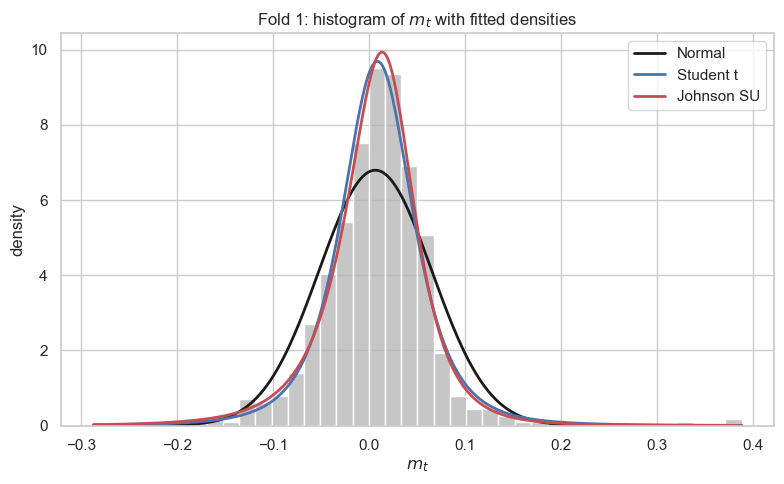

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(fold1, bins=40, stat="density", color="0.7", ax=ax)

xs = np.linspace(fold1.min(), fold1.max(), 400)
colors = {"Normal": "k", "Student t": "C0", "Johnson SU": "C3"}
for name, m in models.items():
    ax.plot(xs, m["frozen"].pdf(xs), color=colors[name], lw=2, label=name)

ax.set(title="Fold 1: histogram of $m_t$ with fitted densities",
       xlabel=r"$m_t$", ylabel="density")
ax.legend()
plt.tight_layout()
plt.show()

## Step 2 — Select via CRPS on fold 2

CRPS for a continuous predictive CDF $F$ and observation $x$ is
$\text{CRPS}(F, x) = \int_{-\infty}^{\infty} \bigl(F(y) - \mathbf{1}\{y \ge x\}\bigr)^2 dy.$
Lower is better. We use the closed form for the Normal and numerical quadrature (with bounds set to the $10^{-6}$ and $1-10^{-6}$ quantiles of the fitted distribution) for the Student-$t$ and Johnson SU.

In [6]:
def mean_crps(name, m):
    obs = fold2.values
    if name == "Normal":
        mu, sigma = m["params"]
        return ps.crps_gaussian(obs, mu=mu, sig=sigma).mean()
    frozen = m["frozen"]
    lo, hi = frozen.ppf(1e-10), frozen.ppf(1 - 1e-10)
    return ps.crps_quadrature(obs, frozen.cdf, lo, hi).mean()

for name, m in models.items():
    m["crps"] = mean_crps(name, m)

crps_table = pd.Series({n: m["crps"] for n, m in models.items()},
                       name="CRPS").sort_values()
crps_table

Johnson SU    0.024490
Student t     0.024524
Normal        0.025273
Name: CRPS, dtype: float64

In [7]:
best_name = crps_table.idxmin()
best = models[best_name]
print(f"Selected model: {best_name}")
print(f"Fitted parameters: {best['params']}")
print(f"Mean CRPS on fold 2: {best['crps']:.6f}")

Selected model: Johnson SU
Fitted parameters: (0.2593060124383558, 1.2581295475500354, 0.019739220160312383, 0.049833044851516836)
Mean CRPS on fold 2: 0.024490


## Step 3 — Diagnose the winner via PIT on fold 2

If the selected $F$ is well calibrated, $p_t = F(m_t)$ should be uniform on $[0,1]$ and its empirical CDF should track the 45° line.

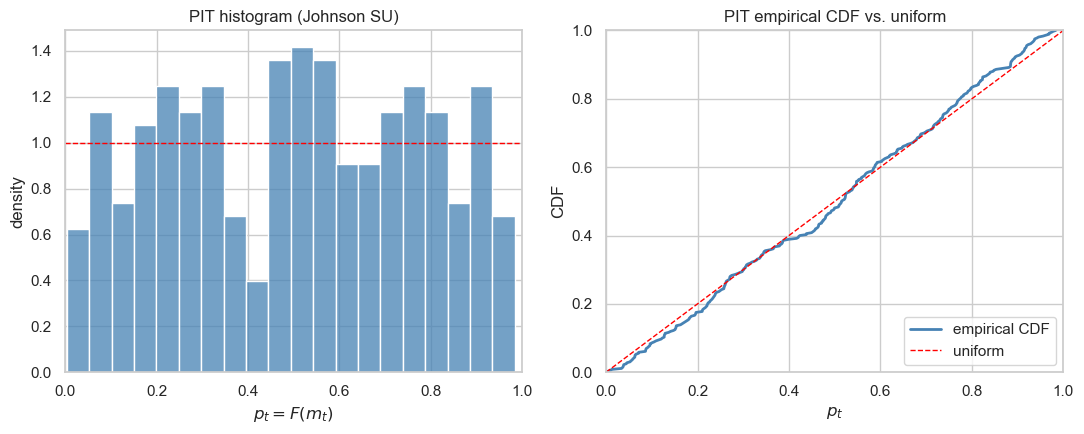

In [8]:
pit = best["frozen"].cdf(fold2.values)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.histplot(pit, bins=20, stat="density", color="steelblue", ax=axes[0])
axes[0].axhline(1.0, color="red", ls="--", lw=1)
axes[0].set(title=f"PIT histogram ({best_name})",
            xlabel=r"$p_t = F(m_t)$", ylabel="density", xlim=(0, 1))

sorted_pit = np.sort(pit)
ecdf = np.arange(1, len(sorted_pit) + 1) / len(sorted_pit)
axes[1].plot(sorted_pit, ecdf, color="steelblue", lw=2, label="empirical CDF")
axes[1].plot([0, 1], [0, 1], color="red", ls="--", lw=1, label="uniform")
axes[1].set(title="PIT empirical CDF vs. uniform",
            xlabel=r"$p_t$", ylabel="CDF", xlim=(0, 1), ylim=(0, 1))
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()